In [1]:
import sys
import os
import numpy as np
import scipy.stats as st

sys.path.append(os.path.abspath('../../code/7_CRM'))
from CRM import CRM, run_lsoda_crossfeeding
from CRM_utils import make_D, numerical_error, has_converged

import matplotlib.pyplot as plt
import time



In [2]:

# Simulation parameters (example, adjust as needed)
n_species = 4
n_resources = 4
timesteps = 100
n_simulations = 10
leakage = 0.2
initial_c_conc = 10
initial_abundance = 1e-2
dt = 0.1
dilution_rate = 0.05
tmax = 2000

In [28]:
def run_one_simulation(n_cs, K_std, leakage, initial_c_conc, initial_abundance,
                   tmax, dilution_rate, n_species, K_mean, transfer=False, 
                   dt = 0.1,
                   method='LSODA',
                   rtol = 1e-9, atol = 1e-9,C_sparsity=0.2,
                   n_transfers=10, transfer_dilution=100, transfer_time=24):
    """
    Run a simulation with the specified parameters and return the final abundance matrix.
    If transfer is True, run the transfer simulation; otherwise, run the standard CRM simulation.
    """
    n_species = 1

    # Fixed arrays
    R0 = np.zeros(n_cs)
    R0[0] = initial_c_conc
    l = leakage * np.ones(n_species)
    N0 = np.ones(n_species) * initial_abundance    

    
    
    if dilution_rate > 0:
        C = np.zeros((n_species, n_cs))
        while np.max(C[:, 0]) < min(10 * dilution_rate, 0.1):
            C = st.gamma.rvs(1.2, 0.01, 0.16, size=(n_species, n_cs))
            C0 = (np.random.uniform(0,1, size = (n_species, n_cs))>C_sparsity).astype(int)
            C = C * C0
    else:
        C = st.gamma.rvs(1.2, 0.01, 0.16, size=(n_species, n_cs))
        C0 = (np.random.uniform(0,1, size = (n_species, n_cs))>C_sparsity).astype(int)
        C = C * C0
        # C = C / np.max(C)
    print('C:', np.max(C))

    D = make_D(n_species, n_cs)
    
    K = np.random.lognormal(K_mean, K_std, (n_species, n_cs))
    # K = np.ones((n_species, n_cs))*0.1
    # K = np.random.lognormal(K_mean, K_std, (n_species, n_cs))
    # K = np.random.lognormal(K_mean, K_std*0.9, (n_species, n_cs))

    # C = st.gamma.rvs(1.2, 0.01, 0.16, size=(n_species, n_cs))
    # C = C / np.max(C)
    # D = make_D(n_species, n_cs)
    
    # D = make_D(n_species, n_cs)
    # print(K[:, 0])
    # print(C[:, 0])
    # l = np.ones(1) * leakage
    # N0 = np.ones(1) * initial_abundance  
    # c = CRM(n_species, n_cs, C[1, None], D=D[1, None], dilution_rate=dilution_rate, l=l, K=K[1, None],
    #         rtol=rtol, atol=atol, g = 1)
    c = CRM(n_species, n_cs, C, D=D, dilution_rate=dilution_rate, l=l, K=K,
        rtol=rtol, atol=atol, g = 1)
    # try:
        # muMatrix,kMatrix,dTensor,lVector,delta,Ns,Nr,N0,R0,t_max
    t0 = time.time()
    sol, success = run_lsoda_crossfeeding(C, K, D, l, dilution_rate, n_species, n_cs, N0, R0, tmax)
    t1 = time.time()
    try:
        sol2 = c.run(tmax, N0, R0, dt=dt, method=method, max_calls = 1e5)
    except RuntimeError as e:
        print(f"Simulation failed with error: {e}")
        sol2 = None
    t2 = time.time()
    print(f"Time lsoda: {t1-t0:.2f} s, time custom: {t2-t1:.2f} s")
    # print(f"Success lsoda: {success}, success custom: {sol2.success}")
    # except RuntimeError as e:
    #     print(f"Simulation failed with error: {e}")
    #     sol = None

        # c = CRM(n_species, n_cs, C, D=D, dilution_rate=dilution_rate, l=l, K=K)
        # sol = c.run(time, N0, R0, dt=dt, method=method)
    # sol, success = None, None
    return sol, success, sol2

In [4]:
error_seeds = [12, 867]

In [5]:
%load_ext autoreload
%autoreload 2

700693
C: 0.4573502036378529


/Users/snorre/miniconda3/envs/CRM/lib/python3.11/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/Users/snorre/miniconda3/envs/CRM/lib/python3.11/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


Required step size is less than spacing between numbers.
Time lsoda: 1.01 s, time custom: 3.66 s
-6.328578603695754e-08


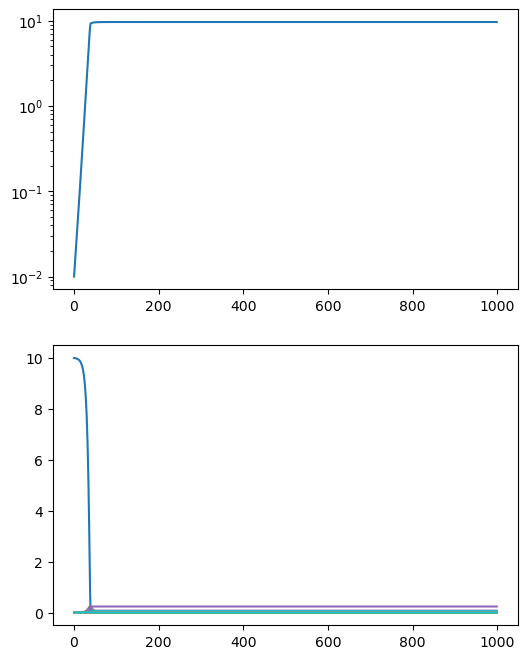

In [36]:
n_cs = 20
n_species = 1
seed = np.random.randint(0, 1e6)
# seed = 867
leakage = 0.2
print(seed)
tmax  =1000
np.random.seed(seed)
sol, success, sol2 = run_one_simulation(
    n_cs=n_cs,
    K_std=2,
    leakage=leakage,
    initial_c_conc=initial_c_conc,
    initial_abundance=initial_abundance,
    tmax=tmax,
    dilution_rate=0,
    n_species=n_species,
    K_mean=-1,
    transfer=False,
    dt=dt,
    method='BDF',
    rtol = 1e-9,
    atol = 1e-9,
    C_sparsity=0.1,
)

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(6,8))
N = sol[:, :n_species]
R = sol[:, n_species:]
ax1.plot(N)
ax1.set_yscale('log')
plt.plot(R)
t_arr = np.linspace(0, 1000,1000)
# res = sol2.sol(t_arr)
# N_arr = res[:n_species, :]
# R_arr = res[n_species:, :]

# ax2.plot(t_arr, N_arr.T)
# plt.yscale('log')
print(R.min())
# print('Min R:', R_arr.min())


In [153]:
K = np.random.lognormal(-1, 2, (4, n_cs))


In [155]:
K[0, None].shape

(1, 20)

In [105]:
t_arr = np.linspace(0, 1000,1000)
res = sol2.sol(t_arr)
N_arr = res[:n_species, :]
R_arr = res[n_species:, :]

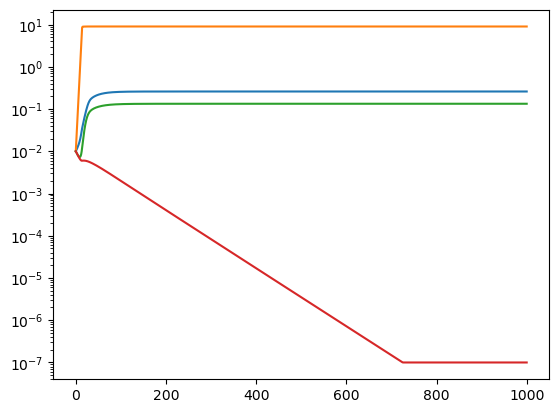

In [109]:
plt.plot(t_arr, N_arr.T)
plt.yscale('log')

In [21]:
C = np.ones((n_species, n_cs))


In [44]:
b

array([1, 2])

In [41]:
np.dot(A, b)

array([ 7, 10, 13])

In [38]:
A = np.array([[1,2, 3],[3,4, 5]]).T
b = np.array([1,2])
A*b

array([[ 1,  6],
       [ 2,  8],
       [ 3, 10]])

In [47]:
D[0, :, j]*C[0]

array([0.04828974, 0.00839748, 0.03919398, 0.        , 0.0116304 ,
       0.07539065, 0.04104829, 0.0086314 , 0.01972544, 0.05225422,
       0.07062214, 0.03014449, 0.01443465, 0.00973337, 0.03218043,
       0.00933142, 0.0228773 , 0.04126313, 0.03207146, 0.04073567])

In [51]:
n_resources = C.shape[1]
dout = np.zeros(n_resources)
for j in range(n_resources):
    dout[j] = (D[0, :, j]*C[0]).sum()


In [52]:
dout

array([1.24053339, 0.63156995, 1.03077809, 0.60795565, 1.27586397,
       0.9652367 , 0.88838691, 1.04044534, 1.20080124, 0.84219047,
       1.00443831, 0.79190082, 0.74679358, 1.65430139, 1.06486593,
       0.8080896 , 0.7996522 , 1.5180692 , 0.88083762, 1.00728964])

In [53]:
np.sum(D[0]*C[0], axis=0)

array([1.24053339, 0.63156995, 1.03077809, 0.60795565, 1.27586397,
       0.9652367 , 0.88838691, 1.04044534, 1.20080124, 0.84219047,
       1.00443831, 0.79190082, 0.74679358, 1.65430139, 1.06486593,
       0.8080896 , 0.7996522 , 1.5180692 , 0.88083762, 1.00728964])

In [ ]:

if sol is None:
    print("Simulation did not complete successfully.")
    # print('C:', C)
    # print('K:', K)
    # print('D:', D)
else:
    # print("Solution shape:", sol.t.shape, sol.t.max(), sol.nfev, sol.njev)

    t_arr = np.arange(0, tmax, 1)

    # if not has_converged(sol):
    #     print("Warning: Solution did not converge.")
    # if numerical_error(sol) > 1e-6:
    #     print("Warning: Numerical error is too high:", numerical_error(sol))
    res = sol.sol(t_arr)
    N_arr = res[:n_species, :]
    R_arr = res[n_species:, :]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    ax1.plot(t_arr, N_arr.T)
    ax1.set_title(f'Species Abundance Over Time')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Abundance')
    ax1.legend([f'Species {i+1}' for i in range(n_species)])
    ax2.plot(t_arr, R_arr.T)
    ax2.set_title('Resource Concentration Over Time')
    ax2.set_xlabel('Time')
    ax1.set_ylim(1e-6, 20)
    ax2.set_ylabel('Concentration')
    # ax2.legend([f'Resource {i+1}' for i in range(n_cs)])
    ax1.set_yscale('log')
    ax2.set_yscale('log')

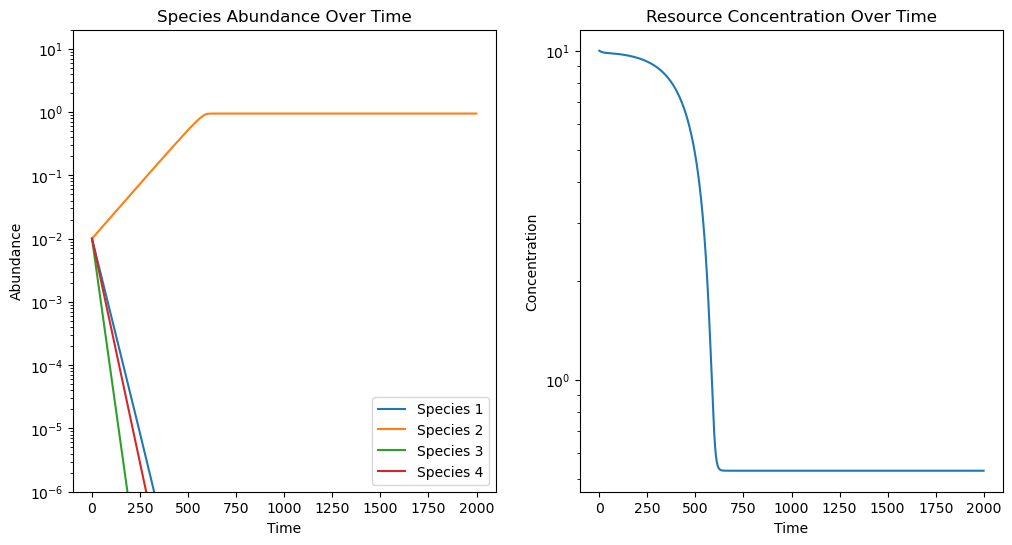

In [7]:
n_species, n_cs, C, D, dilution_rate, l, K, N0, R0, dt, method = params
c = CRM(n_species, n_cs, C, D=D, dilution_rate=dilution_rate, l=leakage, K=K)
sol = c.run(2000, N0, R0, dt=dt, method=method)

if sol is None:
    print("Simulation did not complete successfully.")
    # print('C:', C)
    # print('K:', K)
    # print('D:', D)
else:
    # print("Solution shape:", sol.t.shape, sol.t.max(), sol.nfev, sol.njev)

    t_arr = np.arange(0, tmax, 1)

    # if not has_converged(sol):
    #     print("Warning: Solution did not converge.")
    # if numerical_error(sol) > 1e-6:
    #     print("Warning: Numerical error is too high:", numerical_error(sol))
    res = sol.sol(t_arr)
    N_arr = res[:n_species, :]
    R_arr = res[n_species:, :]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    ax1.plot(t_arr, N_arr.T)
    ax1.set_title(f'Species Abundance Over Time')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Abundance')
    ax1.legend([f'Species {i+1}' for i in range(n_species)])
    ax2.plot(t_arr, R_arr.T)
    ax2.set_title('Resource Concentration Over Time')
    ax2.set_xlabel('Time')
    ax1.set_ylim(1e-6, 20)
    ax2.set_ylabel('Concentration')
    # ax2.legend([f'Resource {i+1}' for i in range(n_cs)])
    ax1.set_yscale('log')
    ax2.set_yscale('log')

In [8]:
K[:, 0]

array([6.04244777, 0.09021909, 1.30062301, 0.15763135])

In [9]:
C[:, 0]

array([0.43903112, 0.73158586, 0.        , 0.22003473])

In [10]:

R0 = np.zeros(n_cs)
R0[0] = initial_c_conc
l = leakage * np.ones(n_species)
N0 = np.ones(n_species) * initial_abundance  
c = CRM(n_species, n_cs, C, D=D, dilution_rate=dilution_rate, l=leakage, K=K)

method = 'BDF'
c.run(tmax, N0, R0, dt=dt, method=method)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.424e-04 ...  1.170e+03  2.000e+03]
        y: [[ 1.000e-02  1.000e-02 ...  0.000e+00  0.000e+00]
            [ 1.000e-02  1.000e-02 ...  9.471e-01  9.471e-01]
            ...
            [ 1.000e-02  1.000e-02 ...  0.000e+00  0.000e+00]
            [ 1.000e+01  1.000e+01 ...  5.290e-01  5.290e-01]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x129b117f0>
 t_events: None
 y_events: None
     nfev: 1045
     njev: 15
      nlu: 96

In [11]:
def calc_Jin(R, C, K):
    # R is a vector of length nr 
    # K is a matrix of length ns x nr
    
    u = R[None, :]/(R[None, :]+K)
    Jin = u * C 
    return Jin

In [12]:
def get_J(n_cs, K_std, leakage, initial_c_conc, initial_abundance,
                   time, dilution_rate, n_species, K_mean, transfer=False, 
                   dt = 0.1,
                   method='BDF',
                   rtol = 1e-3, atol = 1e-6,
                   n_transfers=10, transfer_dilution=100, transfer_time=24):
    """
    Run a simulation with the specified parameters and return the final abundance matrix.
    If transfer is True, run the transfer simulation; otherwise, run the standard CRM simulation.
    """
    

    # Fixed arrays
    R0 = np.zeros(n_cs)
    R0[0] = initial_c_conc
    l = leakage * np.ones(n_species)
    N0 = np.ones(n_species) * initial_abundance    

    
    C = np.zeros((n_species, n_cs))
    while np.max(C[:, 0]) < 2 * dilution_rate:
        C = st.gamma.rvs(1.2, 0.01, 0.16, size=(n_species, n_cs))
        C = C / np.max(C)

    D = make_D(n_species, n_cs)
    
    K = np.random.lognormal(K_mean, K_std, (n_species, n_cs))
    # K = np.random.lognormal(K_mean, K_std, (n_species, n_cs))
    # K = np.random.lognormal(K_mean, K_std*0.9, (n_species, n_cs))

    # C = st.gamma.rvs(1.2, 0.01, 0.16, size=(n_species, n_cs))
    # C = C / np.max(C)
    # D = make_D(n_species, n_cs)
    J =  calc_Jin(R0, C, K)
    # dN_dt = calc_dN_dt(N, g, m, Jin, w, l, ns, nr, dilution_rate)
    # dR_dt = calc_dR_dt(N, Jin, D, w, l, ns, nr, dilution_rate, R_in, R)
    return J
def calc_dN_dt(N, g, m, Jin, w, l, ns, nr, dilution_rate = 0):
    # Vectorized version
    growth = g * (np.sum(w * (1 - l[:, None]) * Jin, axis=1) - m)
    dN_dt = N * (growth - dilution_rate)
    return dN_dt

def calc_dR_dt(N, Jin, D, w, l, ns, nr, dilution_rate = 0, R_in = 0, R = 0):
    # Vectorized leakage calculation
    # D: (ns, nr, nr), w: (nr,), l: (ns,), N: (ns,), Jin: (ns, nr)
    if isinstance(w, (np.ndarray)):
        w_ratio = w[np.newaxis, :, np.newaxis] / w[np.newaxis, np.newaxis, :]  # shape: (1, nr, nr)
    else:
        w_ratio = 1
    lN = (l * N)[:, np.newaxis, np.newaxis]  # shape: (ns, 1, 1)
    Jin_expanded = Jin[:, :, np.newaxis]     # shape: (ns, nr, 1)
    leakage = D * w_ratio * lN * Jin_expanded  # shape: (ns, nr, nr)
    leakage_sum = leakage.sum(axis=(0, 1))     # sum over species and consumed resource

    dR_dt = -np.sum(N[:, np.newaxis] * Jin, axis=0) + leakage_sum

    if dilution_rate > 0:
        dR_dt += (R_in - R) * dilution_rate
    return dR_dt

In [13]:
n_cs = 20
n_species = 4
# seed = np.random.randint(0, 1000)
seed = 867
np.random.seed(seed)
J = get_J(
    n_cs=n_cs,
    K_std=3.0,
    leakage=leakage,
    initial_c_conc=initial_c_conc,
    initial_abundance=initial_abundance,
    time=tmax,
    dilution_rate=dilution_rate,
    n_species=n_species,
    K_mean=0,
    transfer=False,
    dt=dt,
    method='LSODA',
    rtol = 1e-6,
    atol = 1e-6
)



In [14]:
J[J<1e-2]=0


In [15]:
J

array([[0.1418344 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.01043056, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.15250584, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0